In [1]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import pickle
from typing import List, Any

# Change font to respect submission requirements
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = "Times New Roman"
plt.rcParams['font.size'] = 14
plt.rcParams['font.weight'] = 'bold'

# srun -w mauao -c 5 --partition=interactive --pty bash
# srun -w ngongotaha -c 5 --partition=interactive --pty bash
# poetry shell
# jupyter server --no-browser --port=8889
# ssh -L 8889:localhost:8889 ls985@mauao
# ssh -L 8889:localhost:8889 ls985@ngongotaha
HOME_DIR = Path(f"{os.getenv('HOME', '')}")

In [2]:
def read_all_pickle(path: Path) -> List[List[Any]]:
    out = []
    with open(path, 'rb') as f:
        try:
            while True:
                out.append(pickle.load(f))
        except EOFError:
            pass
    return out

def get_rct_dataframe_pickle(path_to_pickle: Path, fn_name = 'configuring fit') -> pd.DataFrame:
    functions = {0: 'init', 1: 'configuring fit', 2: 'configured fit', 3: 'aggregate fit'}
    server_out = read_all_pickle(path_to_pickle)
    df = pd.DataFrame(np.concatenate(server_out), columns=['fn', 'timestamp', 'server_round'], dtype=np.float64)
    df['timedelta'] = df.timestamp.map(lambda a: a - df.timestamp[0])
    df.fn = df.fn.apply(lambda x: functions[x])
    rct = df[df.fn == fn_name].timedelta.diff()
    ret_df = pd.DataFrame(rct.apply(lambda x: x).reset_index(drop=True)[1:])
    ret_df['round'] = list(range(1, len(ret_df)+1))
    ret_df = ret_df.rename(columns={'timedelta': 'rct'})
    return ret_df

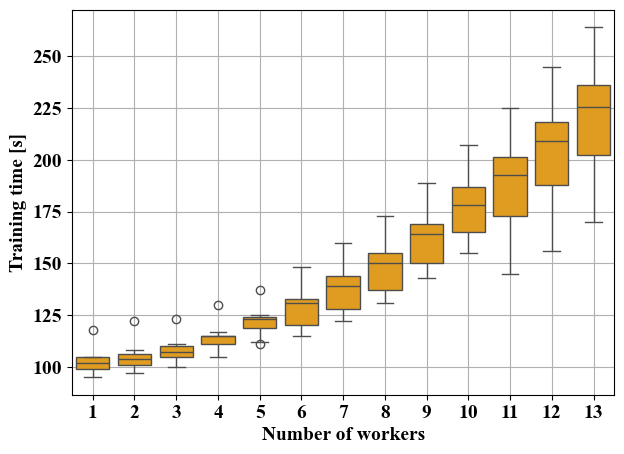

In [4]:
results_root = Path(f"{HOME_DIR}/projects/fertilizer/logs/context/sequential")
dfs = []
for n_workers in results_root.glob('*'):
    for folder in ['context', 'batches', 'round_robin', 'sorted_round_robin']:
        if (n_workers / folder / f'{n_workers.name}_workers').exists():
            df = get_rct_dataframe_pickle(n_workers / folder / f'{n_workers.name}_workers')
            df['placement'] = folder
            df['n_workers'] = n_workers.name
            dfs.append(df)

if len(dfs) > 0:
    fig, ax = plt.subplots(figsize=(7, 5))
    df = pd.concat(dfs)
    df = df[df['round']<11]
    df.rct = df.rct.astype(np.int64)
    df.n_workers = df.n_workers.astype(np.int64).astype('category')
    sns.boxplot(x='n_workers', data=df, y='rct', color='orange', ax=ax)
    y_label = plt.ylabel('Training time [s]')
    x_label = plt.xlabel('Number of workers')
    y_label.set_weight('bold')
    x_label.set_weight('bold')
    plt.grid()
    plt.savefig('interleaving_workers.pdf', format="pdf", dpi=800, bbox_inches='tight')
    plt.savefig('interleaving_workers.png', format="png", dpi=800, bbox_inches='tight')
    plt.show()

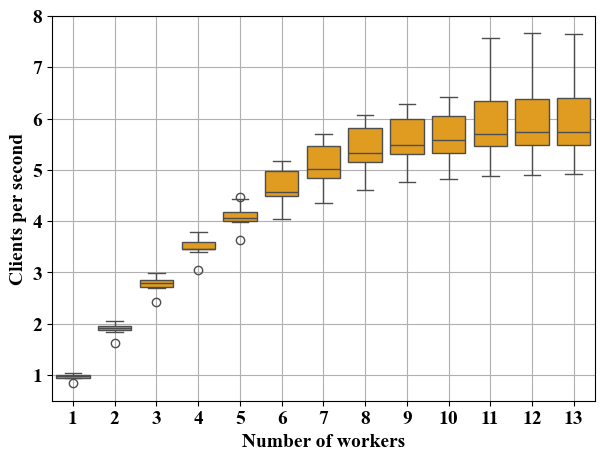

In [5]:
results_root = Path(f"{HOME_DIR}/projects/fertilizer/logs/context/sequential")
dfs = []
for n_workers in results_root.glob('*'):
    for folder in ['context', 'batches', 'round_robin', 'sorted_round_robin']:
        if (n_workers / folder / f'{n_workers.name}_workers').exists():
            df = get_rct_dataframe_pickle(n_workers / folder / f'{n_workers.name}_workers')
            df['placement'] = folder
            df['n_workers'] = n_workers.name
            df['n_clients_per_round'] = df.n_workers.astype(np.int64) * 100
            df['clients_per_second'] = df['n_clients_per_round'] / df['rct']
            dfs.append(df)

if len(dfs) > 0:
    fig, ax = plt.subplots(figsize=(7, 5))
    df = pd.concat(dfs)
    df = df[df['round']<11]
    df.rct = df.rct.astype(np.int64)
    df.n_workers = df.n_workers.astype(np.int64).astype('category')
    sns.boxplot(x='n_workers', data=df, y='clients_per_second', color='orange', ax=ax)
    y_label = plt.ylabel('Clients per second')
    x_label = plt.xlabel('Number of workers')
    y_label.set_weight('bold')
    x_label.set_weight('bold')
    plt.grid()
    plt.savefig('interleaving_workers1.pdf', format="pdf", dpi=800, bbox_inches='tight')
    plt.savefig('interleaving_workers1.png', format="png", dpi=800, bbox_inches='tight')
    plt.show()